'wget' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [8]:
img_height,img_width=32,32
batch_size=20

train_ds=tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\beher\OneDrive\Desktop\DeepLearning\cnn\fruits\fruits\train",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

val_ds=tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\beher\OneDrive\Desktop\DeepLearning\cnn\fruits\fruits\validation",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

test_data=tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\beher\OneDrive\Desktop\DeepLearning\cnn\fruits\fruits\test",
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.


Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


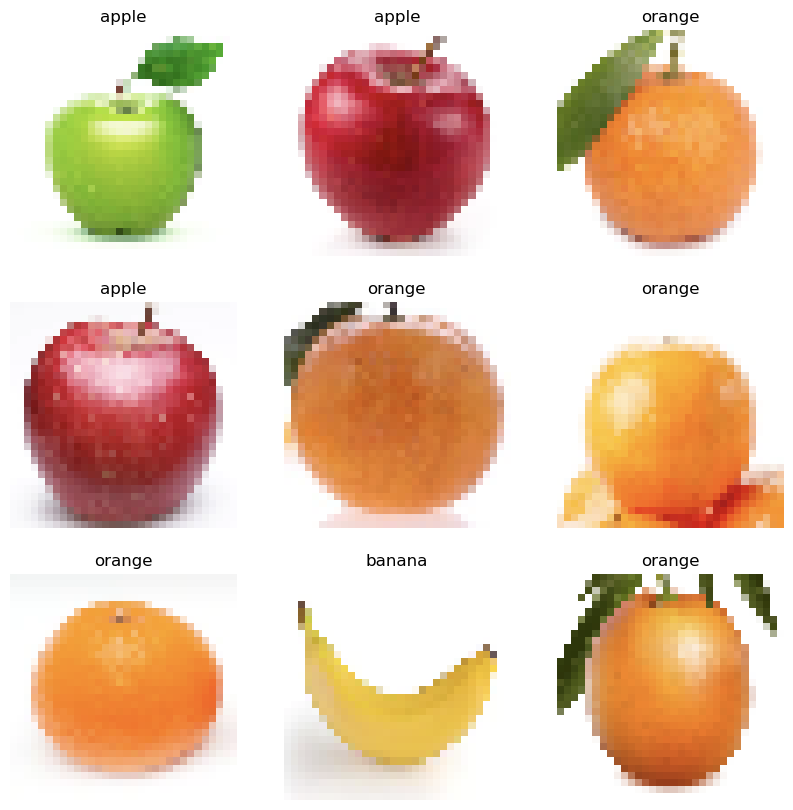

In [10]:
clas_name=['apple','banana','orange']
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i +1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(clas_name[labels[i]])
    plt.axis("off")

In [11]:
model=tf.keras.Sequential(
    [
        tf.keras.layers.Rescaling(1./255),
        tf.keras.layers.Conv2D(32,3,activation='relu'),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(64,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128,activation='softmax'),
        tf.keras.layers.Dense(3)
    ]
)


In [12]:
model.compile(
    optimizer='rmsprop',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [13]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


c:\Users\beher\anaconda3\anconda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.3174 - loss: 1.0985 - val_accuracy: 0.3939 - val_loss: 1.0963
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4152 - loss: 1.0841 - val_accuracy: 0.6061 - val_loss: 1.0471
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5283 - loss: 1.0320 - val_accuracy: 0.3939 - val_loss: 1.0693
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5543 - loss: 0.9886 - val_accuracy: 0.5303 - val_loss: 0.9683
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6739 - loss: 0.9577 - val_accuracy: 0.7273 - val_loss: 0.9435
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7196 - loss: 0.9447 - val_accuracy: 0.5909 - val_loss: 0.9398
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7543 - loss: 0.9115 - val_accuracy: 0.7273 - val_loss: 0.9115
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8043 - loss: 0.8804 - val_accuracy: 0.8485 - val_loss: 0.

In [14]:
model.evaluate(test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9308 - loss: 0.6129


[0.6128681898117065, 0.9307692050933838]

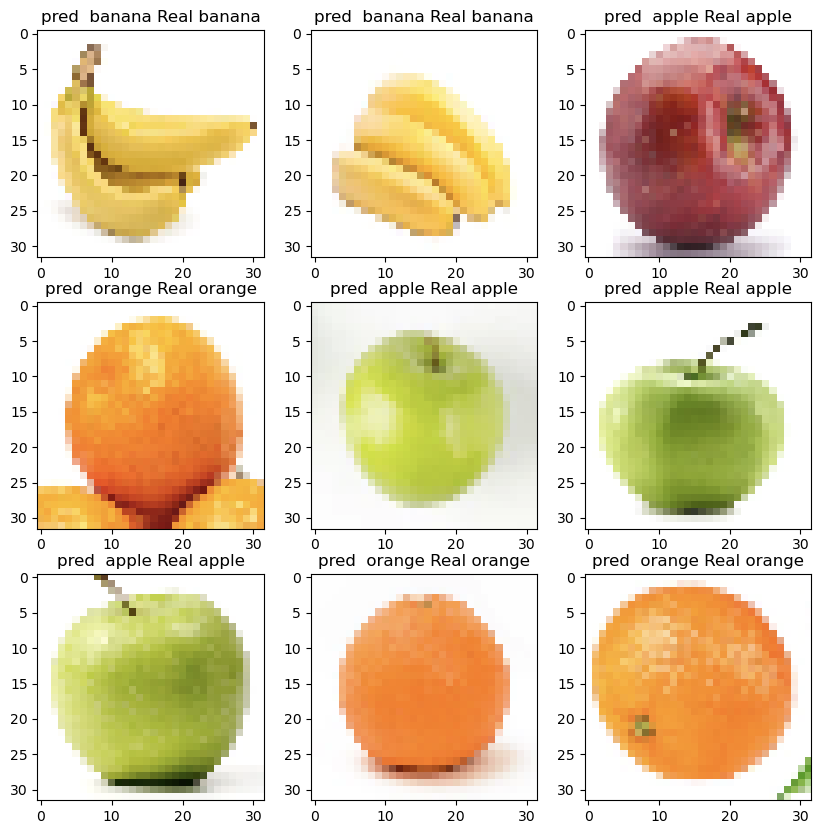

In [17]:
import numpy
plt.figure(figsize=(10, 10))
for images, labels in test_data.take(1):
  classification=model(images)
  for i in range(9):
    ax = plt.subplot(3, 3, i +1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index=numpy.argmax(classification[i])
    plt.title("pred  "+clas_name[index] + " Real "+clas_name[labels[i]])
    # plt.axis("off")